In [1]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [2]:
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']


N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_65396\3800015342.py:2: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', "rb") as input_file:
C:\Users\katie\AppData\Local\Temp\ipykernel_65396\3800015342.py:12: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


[ 3  2  6  0 17  9  8 26 11 20 12 25 21 13 19  7 23 15 14  4  5 24]
>>> best_lam returning: 20.30917620904739
frac null:  0.7691110833127285
frac potent:  0.2308889166872735


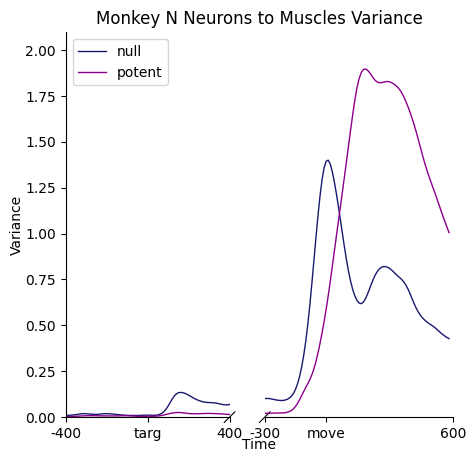

In [3]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

[14 16  5 18 10  6 19 24  2 17  4 21 13  8 15 22  3  1 20 12  7  0]
>>> best_lam returning: 11.937766417144381
frac null:  0.5819730715948893
frac potent:  0.41802692840511085


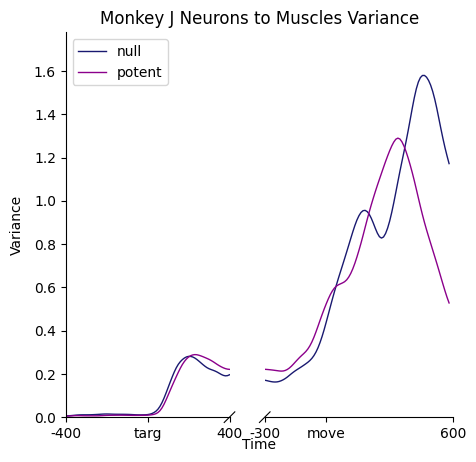

In [4]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[21 16 17  0  3 26  6 15 13 11 23  2  5 22 24  9 20  4  1 25 18 12]
>>> best_lam returning: 11.937766417144381
frac null:  0.5610829719760468
frac potent:  0.4389170280239545


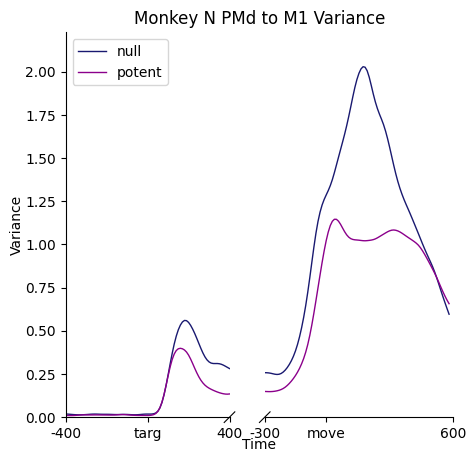

In [23]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[16  3  9 22  7 12  8 18 26  5 10 19 25 21  2 11 15 13  1 20  4 24]
>>> best_lam returning: 34.55107294592218
[12 13  6 15  0  3  7 25 21 17  2 22 14 24  8 19  4 23 10  9  1]
>>> best_lam returning: 34.55107294592218
[18  2 19  0 16 13 12  7  6  9 14  5 23 15 21  8 17 11 20  4]
>>> best_lam returning: 20.30917620904739
[ 1 13 18 16  2  4  6  3 20  7 11 17 10  9  0 14 15]
>>> best_lam returning: 34.55107294592218
frac null:  0.5755559816072255
frac potent:  0.4244440183927744


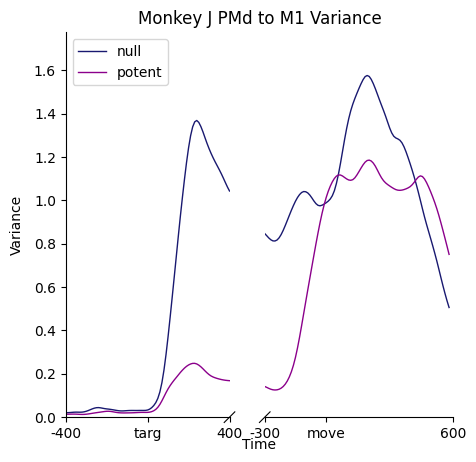

In [6]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[14  1  8 26 23  2 17  6  9 22  7 24 20 15 12  5 13  3 25 11 21 10]
>>> best_lam returning: 20.30917620904739
[12  4 11  7  9  8  1 13 22 25  6  5 10 17 21  3 16 19 24  0 14]
>>> best_lam returning: 20.30917620904739
[18 19 17 22 14 12 10 23  5 11  6 13  0  8  2 21  1  9  3  7]
>>> best_lam returning: 11.937766417144381
[15 16  9  8 13  1 19 11 10  2 12 17  4 14  5  7 18]
>>> best_lam returning: 20.30917620904739
frac null:  0.5899091130731339
frac potent:  0.41009088692686657


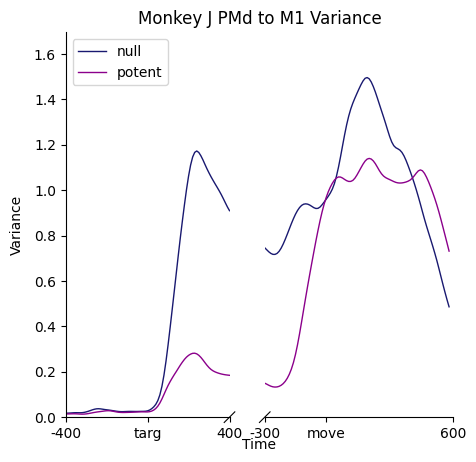

In [7]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[ 2 10  8 22 21  9 17 15 14  3 26 19  1  5  4 24 25 11  7 20  0  6]
>>> best_lam returning: 11.937766417144381
frac null:  0.7677508751991661
frac potent:  0.2322491248008347


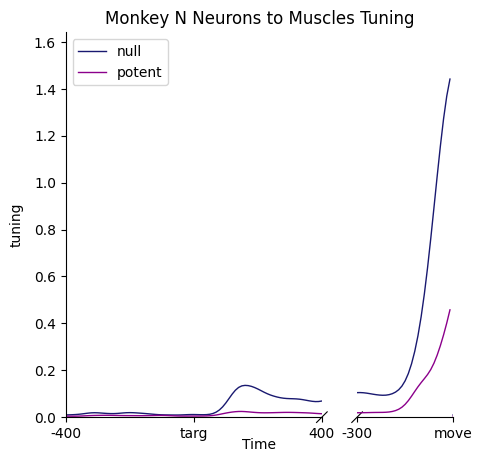

In [8]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [9]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)